<a href="https://colab.research.google.com/github/AstridVillalobosR/Analysis_Telecom/blob/main/S7_Version_Estudiante_Project_ConnectaTel_F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [3]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# cargar archivos
plans = pd.read_csv('plans.csv')
users = pd.read_csv('users_latam.csv')
usage = pd.read_csv('usage.csv')

In [5]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [6]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [7]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


Con esta primera impresión de los datasets, se observan datos importantes para analizar, además un bosquejo claro del contenido de cada uno de ellos.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [8]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [9]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 260.0+ bytes


In [10]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [11]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


In [12]:
#Aqui buscamos la relacion entre duration y length porque sobran 28 datos entre estas dos columnas
usage[(usage["duration"].notnull()) & (usage["length"].notnull())].head()

,id,user_id,type,date,duration,length
1414,1415,10399,text,2024-01-07 09:33:51.260781519,120.00,65.0
1824,1825,12936,text,2024-01-09 06:05:28.868221705,120.00,40.0
1932,1933,10189,text,2024-01-09 17:49:13.603840096,120.00,69.0
2070,2071,13139,call,2024-01-10 08:48:27.432685817,1.68,1490.0
2972,2973,10085,text,2024-01-14 10:46:02.169054226,120.00,68.0


Se identifica que, estos 28 datos son registro en las dos columnas, donde deberia ir solamente registro en una o en la otra pero no juntas, por lo que estos 28 datos pueden ser un error.

---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [13]:
print("*Nulos y porcentaje en users*")
pd.DataFrame({
    'Cantidad de nulos': users.isna().sum(),
    'Porcentaje (%)': users.isna().mean() * 100
})

*Nulos y porcentaje en users*


,Cantidad de nulos,Porcentaje (%)
user_id,0,0.000
first_name,0,0.000
last_name,0,0.000
age,0,0.000
city,469,11.725
reg_date,0,0.000
plan,0,0.000
churn_date,3534,88.350


In [14]:
print("*Nulos y porcentaje en usage*")
pd.DataFrame({
    'Cantidad de nulos': usage.isna().sum(),
    'Porcentaje (%)': usage.isna().mean() * 100
})

*Nulos y porcentaje en usage*


,Cantidad de nulos,Porcentaje (%)
id,0,0.000
user_id,0,0.000
type,0,0.000
date,50,0.125
duration,22076,55.190
length,17896,44.740


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- Indica qué harías: ¿imputar, eliminar, ignorar?

-En el caso de users:
city 11,7% y churn date 88,35%, para city se puede realiazar la revisión de estos nulos y si es posible imputar, en cuanto a churn, aunque se va a revisar, no es necesario modificarla, ya que este porcentaje indica que la gran mayoria de usuarios no se ha retirado del plan.
  
-En el caso de usages:
date 0,1, duration 55,2, length 44,7, para date, seguramente debe ser el tipo de formato asi que se revisará, para duration y lenght, se analizaran las dos columnas, ya que estos nulos corresponden a la relacion entre las dos columnas, si es llamada habrá dato en duration y si es texto habrá dato en length, por lo que habria nulo frente a su columna con dato respectivamente


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [15]:

# explorar columnas numéricas de users

col_numeric = users.select_dtypes(include = "number")
col_numeric.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


In [16]:
#canrtidad de valores invalidos en age
users["age"].le(0).sum()

np.int64(55)

- La columna `user_id`, los datos se concentran entre los usuarios de los codigos 10000 a 14000
- La columna `age`, claramente se observa que ya hay datos erróneos (-999), por lo que puede estar alterando los resultados, en total son 55 datos, los cuales más adelante se les dará su tratamiento respectivo

In [17]:
# explorar columnas numéricas de usage
col_numeric = usage.select_dtypes(include = "number")
col_numeric.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`, son para identificar al usuario, sin embargo con el user_id, se puede observar que los datos o registros se concetran mas desde los 10000 a los 14000
- Las columnas de `duration` y `length`, como lo expliqué anteriormente, tienen faltante pero corresponde a la dinámica de los datos y la relación si es llamada o si es texto, sin embargo al sumar estas dos sifras sobrepasa los 40000 datos, por lo que se identificó anteriormente estos 28 datos que sobrepasan el total, correponden a doble registro en cada columna.

In [18]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


In [19]:
# explorar columnas categóricas de users
#valores unicos y cantidad en la columna city
users["city"].value_counts(dropna = False)

,count
city,
Bogotá,808
CDMX,730
Medellín,616
NaN,469
GDL,450
Cali,424
MTY,407
?,96


- La columna `city`, hacen falta datos, exactamente 469
- La columna `plan`, se observan consistentes los datos arrojados
- Hay una categoria establecida con signo de interrogación, seguramente adjudicado a desconocido (?), el cual se le realizará su trataimento más adelante

In [20]:
# explorar columna categórica de usage
usage['type'].describe()

,type
count,40000
unique,2
top,text
freq,22092


- La columna `type`, hay claridad en los datos, texto fue lo más usado en el plan


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
  En la columnas de age; por revisar en duration y length porque sumadas sobrepasan los 40000 datos y en city
- ¿Qué acción tomarías?
  Revisar cada una de las columnas para determinar la accion correcta, a primera vista en age se podria imputar con el promedio, en city dejaria los Nan o exploraria si pertenece al mismo usuario y esté completo en otra linea. En duration y length, ignoraria por ser tan pocos datos.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [21]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users["reg_date"], errors = "coerce")

In [22]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage["date"], errors = "coerce")

In [23]:
# Extraer solo año en `reg_date` de users
users["year_regdate"] = pd.to_datetime(users["reg_date"]).dt.year

In [24]:
# Años presentes en la columna reg_date
users["year_regdate"].unique()

array([2022, 2026, 2023, 2024], dtype=int32)

In [25]:
#Saber la cantidad de datos por año
users["year_regdate"].value_counts()

,count
year_regdate,
2024,1330
2023,1316
2022,1314
2026,40


En `reg_date`, se observa el año 2026, lo cual se categoriza como dato imposible, también observamos que son solo 40 datos en este año que representan menos del 1%

In [26]:
# Extraer solo año en `date` de usage
usage["year_date"] = pd.to_datetime(usage["date"]).dt.year

In [27]:
# años presentes en la columna date
usage["year_date"].unique()

array([2024.,   nan])

In [28]:
usage["year_date"].value_counts(dropna = False)

,count
year_date,
2024.0,39950
NaN,50


En `date`, se observa que solo hay registros del año 2024, sin embargo se encuentran datos nulos, sabemos que son 50 datos, que representan menos del 1%

Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:
**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (Años muy viejos o sin transcurrir al momento de guardar los datos)
  Aparece 2026, año sin transcurrir y aparecen Nan, datos nulos
- ¿Qué harías con ellas?
  Teniendo en cuenta que representan menos del 1% del total de los datos, para date de usage los dejaría tal cual, como ignorarlos y para reg_date de users, como son datos erróneos los marcaría como nulos.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [29]:
# Reemplazar -999 por la mediana de age
age_mediana = users["age"].median()
users['age'] = users["age"].replace(-999, age_mediana)
# Verificar cambios
users['age'].describe()

,age
count,4000.000000
mean,48.122250
std,17.690408
min,18.000000
25%,33.000000
50%,47.000000
75%,63.000000
max,79.000000


In [30]:
# Reemplazar ? por NA en city
users["city"] = users["city"].replace("?" , pd.NA)
# Verificar cambios
users["city"].value_counts(dropna = False)

,count
city,
Bogotá,808
CDMX,730
Medellín,616
NaN,469
GDL,450
Cali,424
MTY,407
<NA>,96


In [31]:
# Marcar fechas futuras como NA para reg_date
users.loc[users["year_regdate"]>2024, "reg_date"] = np.nan
# Verificar cambios
users["reg_date"].describe()

,reg_date
count,3960
mean,2023-07-03 21:39:41.095273728
min,2022-01-01 00:00:00
25%,2022-10-02 20:17:11.657914368
50%,2023-07-04 10:00:05.401350400
75%,2024-04-03 04:00:05.401350400
max,2024-12-31 00:00:00


Se actualizó la columna reg_date y se encuentra como tipo fecha, además se reemplazó los datos de 2026 como NaN, por lo tanto, a continuación se actualizará tambien la columna de year_regdate, ya que la anterior accion realizada con este comando pues no estaría actualizada, solo fué informativa (ahi encontramos a 2026)

In [32]:
#actualizar columna de solo año de users
users.loc[users["year_regdate"]>2024, "year_regdate"] = np.nan
# Verificar cambios
users["year_regdate"].describe()

,year_regdate
count,3960.000000
mean,2023.004040
std,0.817208
min,2022.000000
25%,2022.000000
50%,2023.000000
75%,2024.000000
max,2024.000000


Por lo tanto ya tenemos nuestra columna de solo año actualizada

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [33]:
# Verificación MAR en usage (Missing At Random) para duration
usage["duration"].isna().groupby(usage["type"]).sum()

,duration
type,
call,0
text,22076


In [34]:
# Verificación MAR en usage (Missing At Random) para length
usage["length"].isna().groupby(usage["type"]).sum()

,length
type,
call,17896
text,0


Efectivamente `duration` y `length`son columnas MAR y se deben dejar como nulos, ya que dependen de la clasificación de la columna type.
Ahora los 28 datos faltantes son los datos que se revisaron inicialmente que "sobraban" y se identificó que estos registraron a la vez dato en length y duration, los cuales corresponden al 0,07%, teniendo en cuenta su baja afectación se van a ignorar.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [35]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
#usage_agg = usage["is_text"]......reset_index()

tot_msj_xus = usage["is_text"].groupby(usage["user_id"]).sum().reset_index()
tot_call_xus = usage["is_call"].groupby(usage["user_id"]).sum().reset_index()
tot_min_xus = usage.groupby("user_id")["duration"].sum().reset_index()

# observar resultado
print(tot_msj_xus.head(3))
print(tot_call_xus.head(3))
print(tot_min_xus.head(3))

   user_id  is_text
0    10000        7
1    10001        5
2    10002        5
   user_id  is_call
0    10000        3
1    10001       10
2    10002        2
   user_id  duration
0    10000     23.70
1    10001     33.18
2    10002     10.74


In [36]:
# Renombrar columnas de texto
tot_msj_xus = tot_msj_xus.rename(columns = {"is_text": "cant_mensajes"})
# observar resultado
#usage_agg.head(3)
tot_msj_xus.head(3)

,user_id,cant_mensajes
0,10000,7
1,10001,5
2,10002,5


In [37]:
# Renombrar columnas de llamadas
tot_call_xus = tot_call_xus.rename(columns = {"is_call": "cant_llamadas"})
# observar resultado
tot_call_xus.head(3)

,user_id,cant_llamadas
0,10000,3
1,10001,10
2,10002,2


In [38]:
# Renombrar columnas de minutos
tot_min_xus = tot_min_xus.rename(columns = {"duration": "cant_minutos_llamada"})
# observar resultado
tot_min_xus.head(3)

,user_id,cant_minutos_llamada
0,10000,23.70
1,10001,33.18
2,10002,10.74


In [39]:
# Combinar la tabla agregada con el dataset de usuarios
#Primero usuarios con total de mensajes
user_profile = pd.merge(users, tot_msj_xus, on = ["user_id"],how = "left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year_regdate,cant_mensajes
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022.0,7.0
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,2022.0,5.0
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022.0,5.0
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022.0,11.0
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022.0,4.0


In [40]:
# Combinar la tabla agregada con el dataset de usuarios
# Ahora el primer merged con llamadas
user_profile = pd.merge(user_profile, tot_call_xus, on = ["user_id"],how = "left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year_regdate,cant_mensajes,cant_llamadas
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022.0,7.0,3.0
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,2022.0,5.0,10.0
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022.0,5.0,2.0
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022.0,11.0,3.0
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022.0,4.0,3.0


In [41]:
# Combinar la tabla agregada con el dataset de usuarios
# Finalmente el segundo merged con minutos
user_profile = pd.merge(user_profile, tot_min_xus, on = ["user_id"],how = "left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year_regdate,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022.0,7.0,3.0,23.70
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,2022.0,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022.0,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022.0,11.0,3.0,8.99
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022.0,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [42]:
# Resumen estadístico de las columnas numéricas
col_num_rel = ["cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]
user_profile[col_num_rel].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


In [43]:
#Identificando donde se enceuntra la fila de dato faltante
#user_profile[col_num_rel].isna().sum()
user_profile[(user_profile["cant_mensajes"].isna()) | (user_profile["cant_llamadas"].isna()) | (user_profile["cant_minutos_llamada"].isna())]

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year_regdate,cant_mensajes,cant_llamadas,cant_minutos_llamada
1082,11082,Luis,Gomez,39,CDMX,2022-10-24 06:31:03.465866468,Basico,NaN,2022.0,NaN,NaN,NaN


In [44]:
# Distribución porcentual del tipo de plan
user_profile["plan"].value_counts(normalize = True)*100

,proportion
plan,
Basico,64.875
Premium,35.125


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

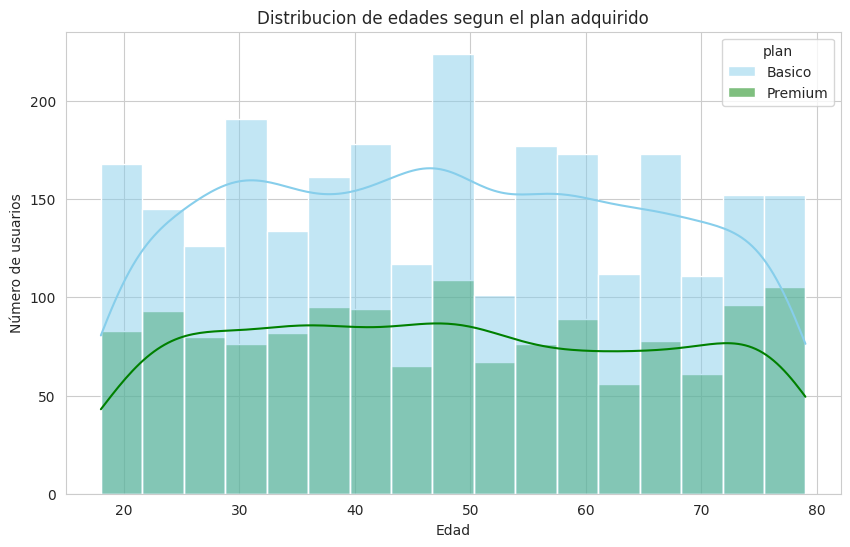

In [45]:
# Histograma para visualizar la edad (age)
sns.set_style("whitegrid")
sns.set_palette("pastel")
plt.figure(figsize=(10,6))
sns.histplot(data = user_profile, x="age", hue="plan", kde=True, palette=['skyblue','green'])
plt.title("Distribucion de edades segun el plan adquirido")
plt.xlabel("Edad")
plt.ylabel("Número de usuarios")
plt.show()


💡Insights:
Ambos planes son adquiridos por usuarios de diferentes edades, por lo cual, no se observa una relación directa entre la edad y el plan adquirido. Sin embargo, el plan Básico presenta una mayor frecuencia de usuarios en prácticamente todos los rangos de edad, siendo el plan más adquirido dentro del conjunto de datos. Por otro lado, el plan Premium mantiene una frecuencia menor a lo largo de todas las edades, aunque muestra ligeros incrementos alrededor de los 45-50 años y cerca de los 80 años, estos incrementos no constituyen un patrón significativo. En general, la distribución de edades es relativamente uniforme y no se observan concentraciones marcadas en un rango específico.


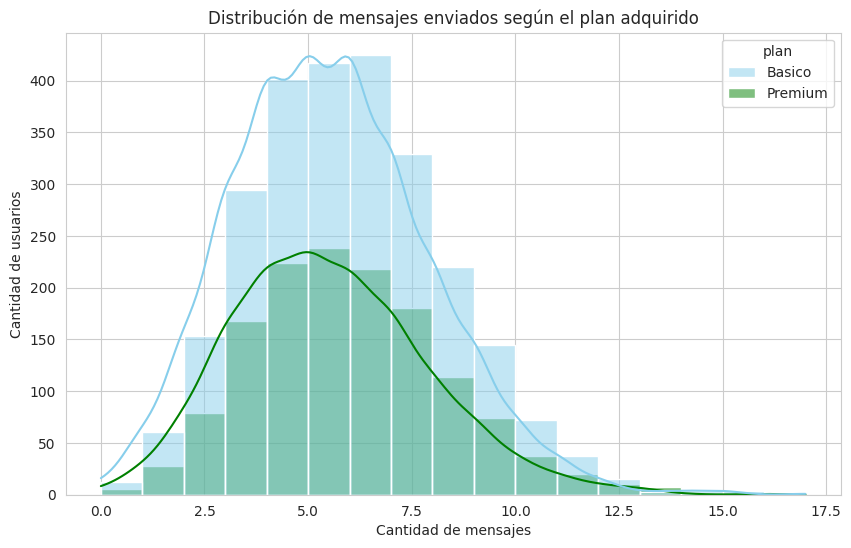

In [46]:
# Histograma para visualizar la cant_mensajes
sns.set_style("whitegrid")
sns.set_palette("pastel")
plt.figure(figsize=(10,6))
sns.histplot(data = user_profile, x="cant_mensajes", bins=17, hue="plan", kde=True, palette=['skyblue','green'])
plt.title("Distribución de mensajes enviados según el plan adquirido")
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Cantidad de usuarios")
plt.show()


💡Insights:
Independientemente del plan adquirido, la mayor concentración de usuarios envía entre 3 y 7 mensajes, siendo este el intervalo con mayor frecuencia. Así mismo, ambas distribuciones presentan un ligero sesgo hacia la derecha, lo que indica que existe un pequeño grupo de usuarios que envía una cantidad considerablemente mayor de mensajes (aproximadamente entre 15 y 17). Sin embargo, estos casos son poco frecuentes en comparación con la mayoría de los usuarios. La forma de la distribución es similar para ambos planes, lo que sugiere que el comportamiento en la cantidad de mensajes enviados no presenta diferencias importantes entre los usuarios de cada plan.

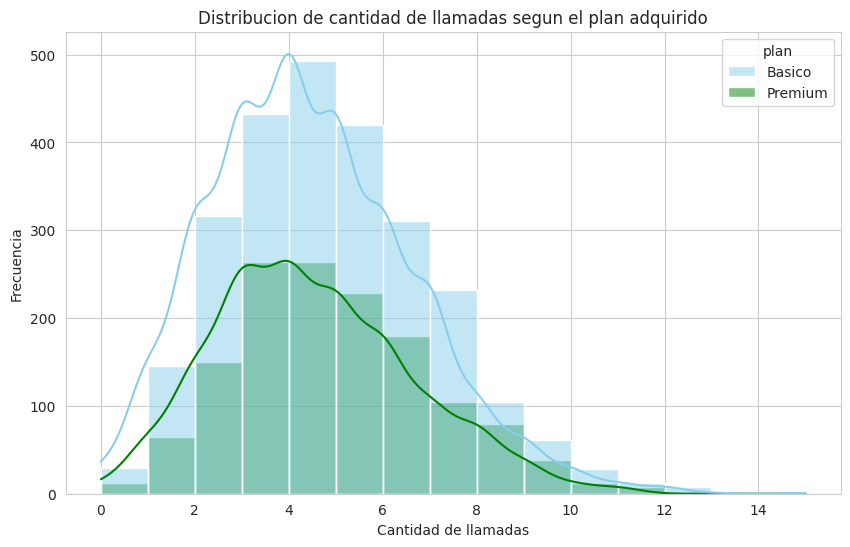

In [47]:
# Histograma para visualizar la cant_llamadas
sns.set_style("whitegrid")
sns.set_palette("pastel")
plt.figure(figsize=(10,6))
sns.histplot(data = user_profile, x="cant_llamadas", bins=15, hue="plan", kde=True, palette=['skyblue','green'])
plt.title("Distribucion de cantidad de llamadas segun el plan adquirido")
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Frecuencia")
plt.show()


💡Insights:
La distribución de llamadas es similar para ambos planes, con una mayor concentración de usuarios entre 3 y 6 llamadas. También, ambas distribuciones presentan un ligero sesgo positivo hacia la derecha, lo que evidencia la existencia de pocos usuarios con un número elevado de llamadas (superior a 12), aunque estos representan una proporción reducida del total.

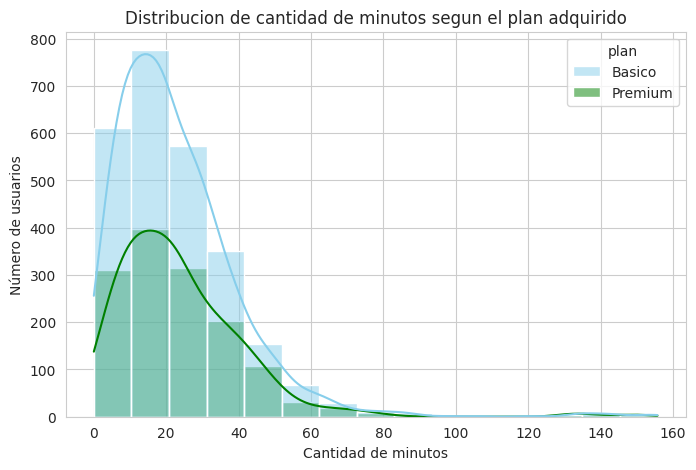

In [48]:
# Histograma para visualizar la cant_minutos_llamada
sns.set_style("whitegrid")
sns.set_palette("pastel")
plt.figure(figsize=(8,5))
sns.histplot(data = user_profile, x="cant_minutos_llamada", bins=15, hue="plan", kde=True, palette=['skyblue','green'])
plt.title("Distribucion de cantidad de minutos segun el plan adquirido")
plt.xlabel("Cantidad de minutos")
plt.ylabel("Número de usuarios")
plt.show()


💡Insights:
La duración de las llamadas presenta una distribución con un marcado sesgo hacia la derecha, evidenciando la presencia de pocos usuarios con llamadas de larga duración superiores a los 80 minutos. No obstante, la mayor concentración de usuarios realizó llamadas entre 0 y 30 minutos. Asimismo, ambos planes presentan una distribución muy similar, por lo que no se identifican diferencias relevantes en la duración de las llamadas según el plan adquirido.

**En todas las gráficas se observa una mayor concentración de usuarios en el plan Básico y en ambos planes presentan distribuciones similares en las variables analizadas, sin evidenciar diferencias significativas en su comportamiento.**

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

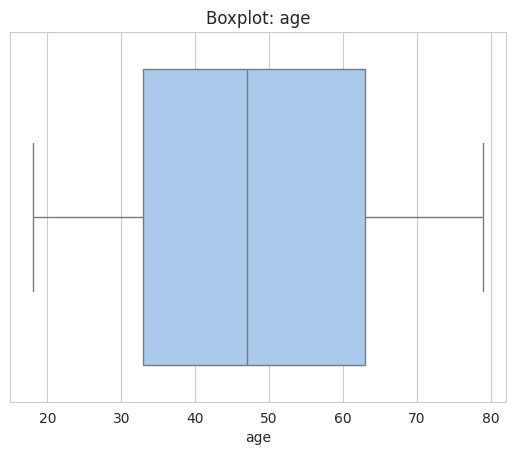

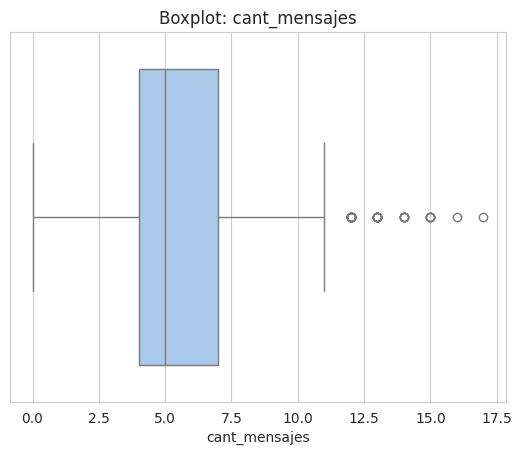

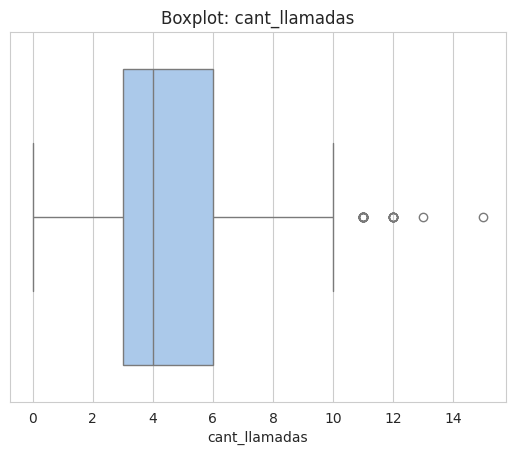

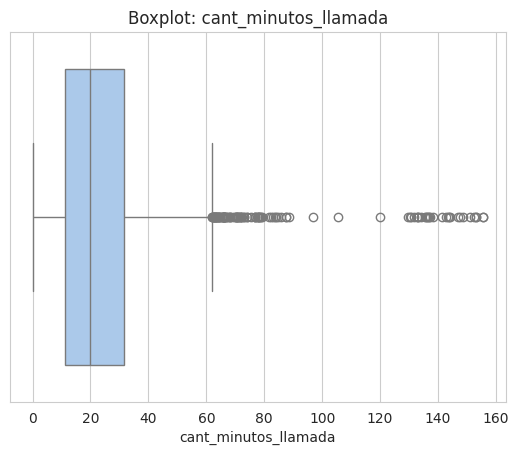

In [49]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col)
    plt.title(f"Boxplot: {col}")
    plt.show()


💡Insights:
- Age: No se observan valores atípicos, lo que indica una distribución consistente en la variable edad. El 50% central de las observaciones se encuentra aproximadamente entre los 32 y 63 años (rango intercuartílico), mientras que el resto de las edades se distribuye por debajo y por encima de este intervalo sin presentar valores extremos.
- cant_mensajes y cant_llamadas: Ambas variables presentan una distribución similar, con la mayor concentración de observaciones en valores bajos y medios. Además, se identifican valores atípicos en el extremo derecho, correspondientes a usuarios que registran una cantidad significativamente mayor de mensajes o llamadas que el resto.
- cant_minutos_llamada:Al igual que las variables cant_mensajes y cant_llamadas, presenta valores atípicos hacia la derecha. Sin embargo, el sesgo positivo es mucho más marcado y se observa una mayor cantidad de outliers, lo que evidencia que, aunque la mayoría de las llamadas son de corta duración, existe un grupo reducido de usuarios con llamadas considerablemente más largas.

In [50]:
# Calcular límites con el método IQR
columnas_limites = ["cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    Ext_sup = Q3+1.5*IQR
    print(f" Extremo_superior {col}: {Ext_sup}")

 Extremo_superior cant_mensajes: 11.5
 Extremo_superior cant_llamadas: 10.5
 Extremo_superior cant_minutos_llamada: 61.8575


In [51]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: mantener o no outliers, porqué?
Presenta algunos valores altos, pero se mantienen debido a que representan usuarios con un mayor nivel de actividad. Estos valores son posibles dentro del contexto de uso del servicio y no se consideran errores.
- cant_llamadas: mantener o no outliers, porqué?
Existen valores altos que corresponden a usuarios con una mayor frecuencia de llamadas, al tratarse de un comportamiento plausible, se conservan sin realizar modificaciones.
- cant_minutos_llamada: mantener o no outliers, porqué?
Hay una mayor dispersión y valores elevados, sin embargo, esta variable corresponde al total de minutos de llamadas acumulados por usuario durante el período analizado, no a la duración de una única llamada. Por ello, el valor máximo de aproximadamente 156 minutos es razonable y puede reflejar usuarios con un mayor consumo del servicio, por lo tanto, se conservan estos valores sin aplicar técnicas de capado o winsorización.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [52]:
# Crear columna grupo_uso
user_profile["grupo_uso"] = np.where((user_profile["cant_llamadas"]<5) & (user_profile["cant_mensajes"]<5), "Bajo uso",
                                      np.where((user_profile["cant_llamadas"]<10) & (user_profile["cant_mensajes"]<10), "Uso medio", "Alto uso"))

In [53]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year_regdate,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022.0,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,2022.0,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022.0,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022.0,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022.0,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [54]:
# Crear columna grupo_edad
user_profile["grupo_edad"] = np.where((user_profile["age"]< 30), "Joven",
                                      np.where(user_profile["age"]< 60, "Adulto", "Adulto Mayor"))

In [55]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year_regdate,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022.0,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,2022.0,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022.0,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022.0,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022.0,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

/tmp/ipykernel_1004/2347754862.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=user_profile, x="grupo_uso", order=orden, palette="viridis")


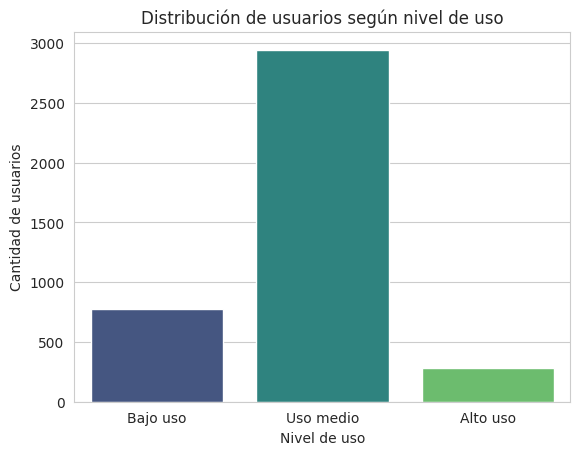

In [56]:
# Visualización de los segmentos por uso
orden = ["Bajo uso", "Uso medio", "Alto uso"]
sns.countplot(data=user_profile, x="grupo_uso", order=orden, palette="viridis")
plt.title("Distribución de usuarios según nivel de uso")
plt.xlabel("Nivel de uso")
plt.ylabel("Cantidad de usuarios")
plt.show()

/tmp/ipykernel_1004/4057716010.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=user_profile, x="grupo_edad", order=orden, palette= "viridis")


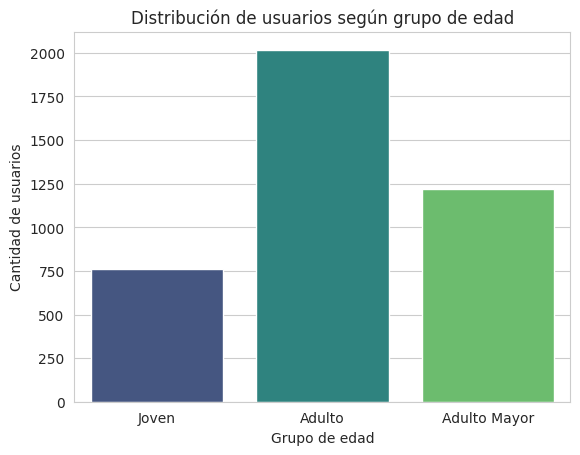

In [57]:
# Visualización de los segmentos por edad
orden =["Joven", "Adulto", "Adulto Mayor"]
sns.countplot(data=user_profile, x="grupo_edad", order=orden, palette= "viridis")
plt.title("Distribución de usuarios según grupo de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Cantidad de usuarios")
plt.show()

En las siguientes líneas realicé unas agrupaciones para observar también el patrón de terminación o cancelación del plan

In [58]:
user_profile["churn"] = user_profile["churn_date"].notna()

In [59]:
#Tasa de cancelaciones por tipo de plan
user_profile.groupby("plan")["churn"].mean()*100

,churn
plan,
Basico,11.483622
Premium,11.957295


In [60]:
#Tasa de cancelaciones por grupo de uso
tabla_uso = (user_profile.groupby("grupo_uso").agg(Total_usuarios=("grupo_uso", "count"),Cancelaciones=("churn", "sum")))

tabla_uso["Tasa_churn (%)"] = (tabla_uso["Cancelaciones"] / tabla_uso["Total_usuarios"] * 100).round(2)

tabla_uso

,Total_usuarios,Cancelaciones,Tasa_churn (%)
grupo_uso,,,
Alto uso,279,39,13.98
Bajo uso,778,89,11.44
Uso medio,2943,338,11.48


In [61]:
#tasa de cancelaciones por grupo edad
tabla_edad = (user_profile.groupby("grupo_edad").agg(Total_usuarios=("grupo_edad", "count"),Cancelaciones=("churn", "sum")))

tabla_edad["Tasa_churn (%)"] = (tabla_edad["Cancelaciones"] / tabla_edad["Total_usuarios"] * 100).round(2)

tabla_edad

,Total_usuarios,Cancelaciones,Tasa_churn (%)
grupo_edad,,,
Adulto,2018,252,12.49
Adulto Mayor,1222,134,10.97
Joven,760,80,10.53



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

Inicialmente se identificaron datos no válidos o erróneos y valores nulos. En la columna ciudad, los valores faltantes o no válidos representaban aproximadamente el 11% de los registros. También se encontraron valores NaN en las columnas duración y longitud, correspondientes aproximadamente al 55% y 44% de los registros, respectivamente. Adicionalmente, se identificaron valores atípicos como -999 y fechas no válidas, como registros con años posteriores al periodo analizado. Estos problemas se consideraron y adecuaron durante la preparación de los datos para evitar afectar los resultados del análisis.

🔍 **Segmentos por Edad**

Se clasificaron los clientes en los grupos joven, adulto y adulto mayor. Se observa una mayor concentración de clientes en el grupo adulto, mientras que los grupos joven y adulto mayor presentan una menor participación.

📊 **Segmentos por Nivel de Uso**

El nivel de uso se clasificó en bajo, medio y alto, teniendo en cuenta la cantidad de mensajes y llamadas realizadas por cada usuario. Se observa claramente que la mayoría de los clientes presenta un nivel de uso medio, mientras que los segmentos de bajo y alto uso representan una proporción considerablemente menor.

➡️ Esto sugiere que la base de clientes está principalmente conformada por usuarios adultos con un nivel de uso medio, mientras que los demás grupos de edad y niveles de uso representan una proporción menor.

Revisando el comportamiento de Churn, se evidencia que, el plan Básico registra un mayor número de cancelaciones en términos absolutos, al analizar la tasa de churn se observa un comportamiento muy similar entre ambos planes (11,48 % en Básico y 11,96 % en Premium). En cuanto a los segmentos de uso, los usuarios de alto uso presentan la mayor tasa de cancelación (13,98 %), lo que podría indicar una oportunidad para revisar si las características actuales de los planes satisfacen las necesidades de este grupo de clientes. Por edad, el grupo adulto registra una tasa de churn ligeramente superior (12,49 %), aunque la diferencia respecto a los demás grupos es moderada.

📈 Patrones de uso extremo (outliers)
En cuanto a los outlier indentificados, estos indican la existencia de un grupo reducido de usuarios con un consumo considerablemente superior al del resto de la población. Estos patrones sugieren que, aunque la mayoría de los clientes presenta un comportamiento de uso moderado, existe un segmento con necesidades de comunicación más intensivas.

💡 **Recomendaciones**
1. Fortalecer la fidelización del segmento principal.
Los usuarios con un nivel de uso medio representan la mayor parte de la base de clientes. Implementar estrategias orientadas a mantener su satisfacción contribuiría a conservar una proporción importante de los clientes actuales.

2. Diseñar estrategias para usuarios de alto consumo.
Los usuarios de alto uso presentan la mayor tasa de churn (13,98 %), por lo que sería conveniente revisar si los beneficios actuales de los planes responden a sus necesidades y evaluar estrategias específicas de retención.

3. Aprovechar la información de los outliers.
Los usuarios identificados como outliers representan un grupo de consumo significativamente superior al promedio. Analizar sus patrones de comportamiento puede servir como base para diseñar ofertas diferenciadas o beneficios específicos para clientes con necesidades de comunicación intensivas.

4. Relación costo o ingreso total de usuarios por tipo de plan.
Considerando únicamente la tarifa mensual de cada plan, el plan Premium representaría un mayor ingreso mensual estimado para ConnectaTel (USD 35.125 frente a USD 31.140 del plan Básico), a pesar de contar con un menor número de usuarios. Esto sugiere que las estrategias de retención y fidelización de los clientes Premium pueden tener un impacto importante en los ingresos de la empresa, por lo que es importante mantener y obtener más usuarios premium para beneficio de la empresa. (La operacion se realizó tomando el dato del valor por plan y cantidad de usuarios de cada uno)

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`